In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt

# Add the repo folder for imports
dirpath_repo_root = Path().resolve().parents[2]
sys.path.append(str(dirpath_repo_root))
print(f'Repo root: {dirpath_repo_root}')

from analysis.ou_tuning import batch_utils
import fi_utils

Repo root: /ddn/niknovikov19/repo/A1_OUinp


In [2]:
#exp_name = 'exp_it5a_gkdr_2_gkap_0.2_gcat_0_gcal_0_gcan_0_gkbk_0_gih_0_amp_0.75_1.5_rx_1_150_wx_1_1_sz_2_4_1_xsec_apic_isec_Adend1_irange_-0.05_0.15'
exp_name = 'exp_tc_gkdr_1_amp_0.25_2.0_rx_1_500_wx_0.1_0.1_sz_3_3_1_xsec_soma_isec_soma_irange_-0.01_0'

dirpath_exp = (dirpath_repo_root / 'exp_results/batch_unconn/fi_tuning' / exp_name)
dirpath_cfg = dirpath_exp / 'cfg'
fname_cfg_templ = '*_cfg.json'

# Populations to read from the result jsons
pops_used = ['TC']

# Extract (param_grid -> job_id) xarray from cfg folder
job_idx_xr = batch_utils.extract_batch_params_to_xr(
    dirpath_cfg,
    cfg_param_fields={
        'amp': 'ou_ramp_offset',   # xarray : json
        'wx': 'bkg_w',
        'rx': 'bkg_r'
    },
    fname_cfg_templ=fname_cfg_templ,
    job_pos_in_fname=0
)
job_idx_xr

<xarray.DataArray 'job_id' (amp: 3, wx: 1, rx: 3)> Size: 72B
array([[[0, 1, 2]],

       [[3, 4, 5]],

       [[6, 7, 8]]])
Coordinates:
  * amp      (amp) float64 24B 0.25 1.0 2.0
  * wx       (wx) float64 8B 0.1
  * rx       (rx) int64 24B 1 250 500

In [3]:
R, V = {}, {}

for pop in pops_used:
    R[pop] = batch_utils.collect_batch_xr_data(
        job_idx_xr,
        dirpath_data=(dirpath_exp / 'rates_xr'),
        fname_data_templ=('{job:05d}_*' + pop + '.nc')
    )
    V[pop] = batch_utils.collect_batch_xr_data(
        job_idx_xr,
        dirpath_data=(dirpath_exp / 'vstats_xr'),
        fname_data_templ=('{job:05d}_*' + pop + '.nc')
    )

R[pops_used[0]]

<xarray.DataArray (amp: 3, wx: 1, rx: 3, interval: 2, cell: 116)> Size: 17kB
array([[[[[  0.,   0.,   0., ..., 106., 106., 108.],
          [  0.,   0.,   0., ..., 110., 111., 112.]],

         [[  0.,   0.,   0., ..., 107., 108., 109.],
          [  0.,   0.,   0., ..., 111., 113., 113.]],

         [[  0.,   0.,   0., ..., 108., 110., 111.],
          [  0.,   0.,   0., ..., 113., 114., 115.]]]],



       [[[[  0.,   0.,   0., ..., 106., 106., 108.],
          [  0.,   0.,   0., ..., 110., 111., 112.]],

         [[  0.,   0.,   0., ..., 107., 108., 109.],
          [  0.,   0.,   0., ..., 112., 113., 114.]],

         [[  0.,   0.,   0., ..., 108., 110., 111.],
          [  0.,   0.,   0., ..., 114., 114., 115.]]]],



       [[[[  0.,   0.,   0., ..., 106., 106., 108.],
          [  0.,   0.,   0., ..., 110., 110., 112.]],

         [[  0.,   0.,   0., ..., 107., 108., 109.],
          [  0.,   0.,   0., ..., 111., 112., 113.]],

         [[  0.,   0.,   0., ..., 108., 110., 111.],
          [  0.,   0.,   0., ..., 113., 114., 114.]]]]],
      shape=(3, 1, 3, 2, 116))
Coordinates:
  * amp         (amp) float64 24B 0.25 1.0 2.0
  * wx          (wx) float64 8B 0.1
  * rx          (rx) int64 24B 1 250 500
  * cell        (cell) int32 464B 0 1 2 3 4 5 6 ... 109 110 111 112 113 114 115
    I           (cell) float64 928B ...
    time_range  (interval) object 16B ...
  * interval    (interval) object 16B 'pre' 'post'

Text(0.5, 0, 'Input current')

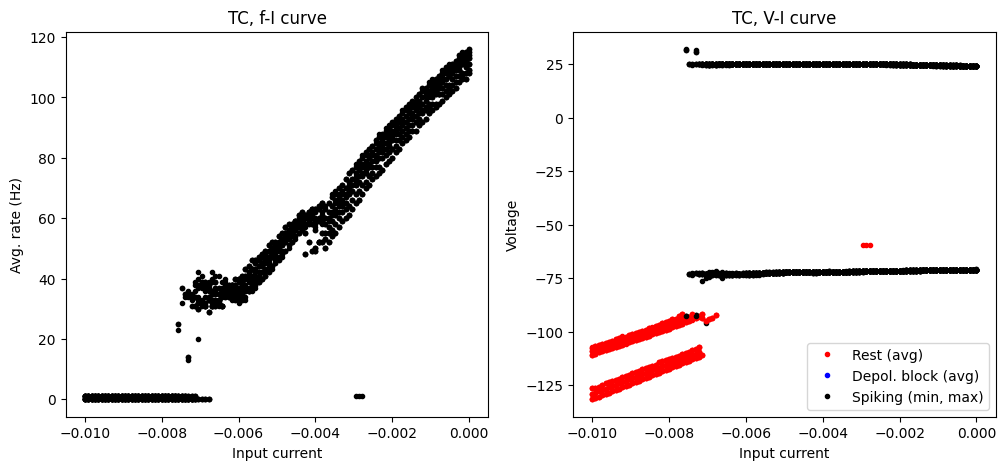

In [4]:
pop = pops_used[0]

plt.figure(figsize=(12, 5))

for n, amp in enumerate(R[pop].coords['amp']):
    for m, rx in enumerate(R[pop].coords['rx']):
        R_ = R[pop].sel(amp=amp, rx=rx).isel(wx=0)
        V_ = V[pop].sel(amp=amp, rx=rx).isel(wx=0)
        plt.subplot(1, 2, 1)
        fi_utils.plot_fi_curve(R_, pop, 'k.', legend=False)
        plt.subplot(1, 2, 2)
        fi_utils.plot_vi_curve(V_, pops_used[0])

plt.subplot(1, 2, 1)
plt.title(f'{pop}, f-I curve')
plt.xlabel('Input current')
plt.subplot(1, 2, 2)
plt.title(f'{pop}, V-I curve')
plt.xlabel('Input current')

Text(0.5, 0, 'Input current')

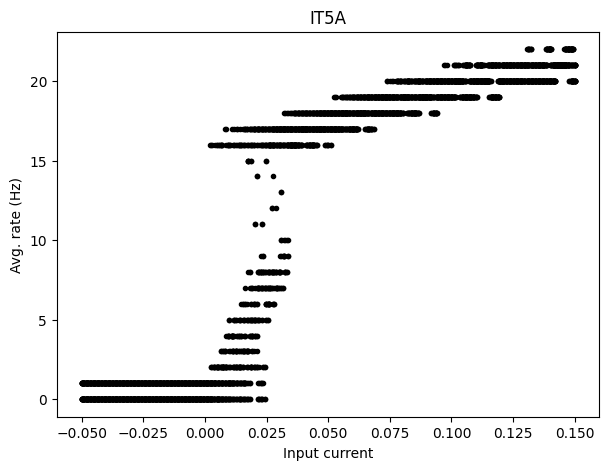

In [4]:
pop = pops_used[0]

plt.figure(figsize=(7, 5))
nx, ny = 3, 2

for n, amp in enumerate(R.coords['amp']):
    for m, rx in enumerate(R.coords['rx']):
        R_ = R.sel(amp=amp, rx=rx).isel(wx=0)
        fi_utils.plot_fi_curve(R_, pop, 'k.', legend=False)
        
plt.title(f'{pop}')
plt.xlabel('Input current')
        

Text(0.5, 0, 'Input current')

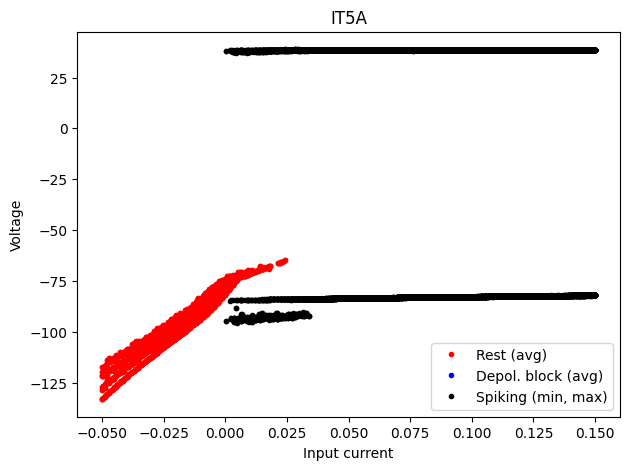

In [6]:
pop = pops_used[0]

plt.figure(figsize=(7, 5))

for n, amp in enumerate(R.coords['amp']):
    for m, rx in enumerate(R.coords['rx']):
        V_ = V.sel(amp=amp, rx=rx).isel(wx=0)
        fi_utils.plot_vi_curve(V_, pops_used[0])
  
plt.title(f'{pop}')
plt.xlabel('Input current')